## Code

  Abhishek V Ammanagi  |  2023BCSE07AED500
  Experiment 7: Object Detection + Bounding Boxes


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv2d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 3)         │        771 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ box_output (Dense)  │ (None, 4)         │      1,028 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 128,071 (500.28 KB)

 Trainable params: 128,071 (500.28 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - box_output_loss: 0.0308 - class_output_accuracy: 0.3562 - class_output_loss: 1.1053 - loss: 1.2592 - val_box_output_loss: 0.0284 - val_class_output_accuracy: 0.3750 - val_class_output_loss: 1.0989 - val_loss: 1.2396
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - box_output_loss: 0.0295 - class_output_accuracy: 0.3500 - class_output_loss: 1.1020 - loss: 1.2494 - val_box_output_loss: 0.0281 - val_class_output_accuracy: 0.3750 - val_class_output_loss: 1.0970 - val_loss: 1.2375
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - box_output_loss: 0.0292 - class_output_accuracy: 0.3417 - class_output_loss: 1.1041 - loss: 1.2503 - val_box_output_loss: 0.0286 - val_class_output_accuracy: 0.3750 - val_class_output_loss: 1.0961 - val_loss: 1.2387
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - box_output_loss: 0.0295 - class_output_accuracy: 0.3292 - class_output_loss: 1.1011 - loss: 1.2486 - val_box_output_loss: 0.0282 - val_c

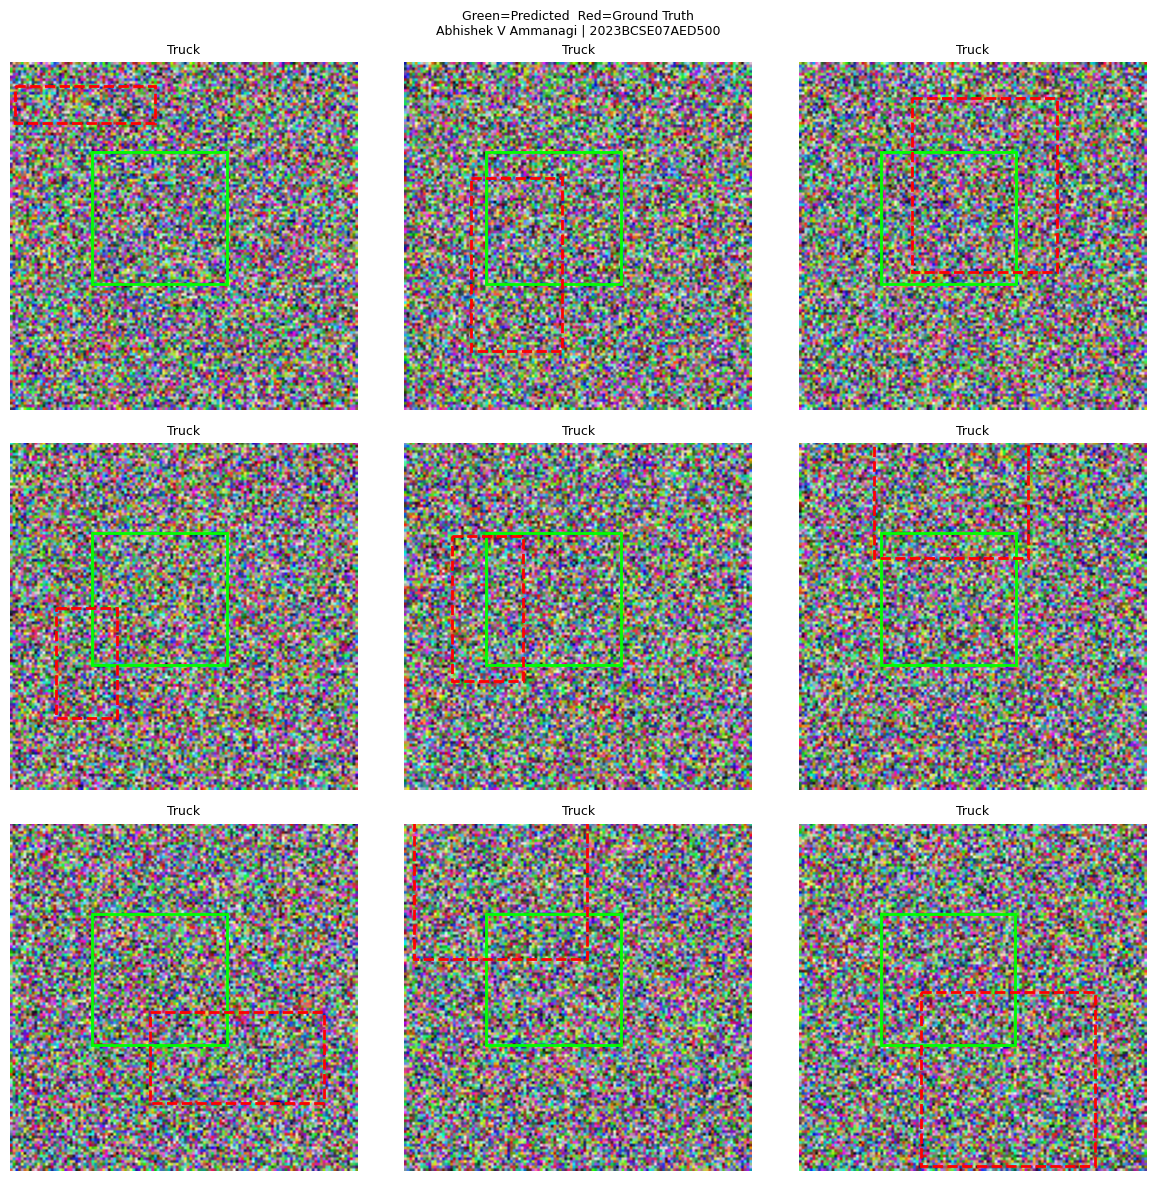

Abhishek V Ammanagi | 2023BCSE07AED500


In [1]:
# Experiment 7 – Object Detection with Bounding Boxes
# Abhishek V Ammanagi | 2023BCSE07AED500

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import tensorflow as tf
from tensorflow.keras import layers, Model, Input

print("=" * 55)
print("  Abhishek V Ammanagi  |  2023BCSE07AED500")
print("  Experiment 7: Object Detection + Bounding Boxes")
print("=" * 55)

IMG    = 128; N = 600; NC = 3; EPOCHS = 20
np.random.seed(42)
CLASS_NAMES = ['Car','Truck','Motorcycle']

X      = np.random.rand(N,IMG,IMG,3).astype('float32')
labels = np.random.randint(0,NC,N)
boxes  = np.random.uniform(0.1,0.8,(N,4)).astype('float32')
boxes[:,2:] = np.clip(boxes[:,2:],0.05,0.5)
y_cls  = tf.keras.utils.to_categorical(labels,NC)

sp = int(0.8*N)
X_tr,X_te         = X[:sp],X[sp:]
y_cls_tr,y_cls_te = y_cls[:sp],y_cls[sp:]
y_box_tr,y_box_te = boxes[:sp],boxes[sp:]

inp = Input(shape=(IMG,IMG,3))
x   = layers.Conv2D(32,3,activation='relu',padding='same')(inp)
x   = layers.MaxPooling2D(2)(x)
x   = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x   = layers.MaxPooling2D(2)(x)
x   = layers.Conv2D(128,3,activation='relu',padding='same')(x)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256,activation='relu')(x)
x   = layers.Dropout(0.4)(x)
cls = layers.Dense(NC,activation='softmax',name='class_output')(x)
box = layers.Dense(4, activation='sigmoid',name='box_output')(x)

model = Model(inp,[cls,box])
model.compile(optimizer='adam',
    loss={'class_output':'categorical_crossentropy','box_output':'mse'},
    loss_weights={'class_output':1.0,'box_output':5.0},
    metrics={'class_output':'accuracy'})
model.summary()

history = model.fit(X_tr,
    {'class_output':y_cls_tr,'box_output':y_box_tr},
    validation_data=(X_te,
        {'class_output':y_cls_te,'box_output':y_box_te}),
    epochs=EPOCHS,batch_size=32,verbose=1)

res = model.evaluate(X_te,
    {'class_output':y_cls_te,'box_output':y_box_te},verbose=0)
print(f"\nClassification Accuracy: {res[3]:.4f}")

cls_p, box_p = model.predict(X_te[:9])
fig, axes = plt.subplots(3,3,figsize=(12,12))
for i,ax in enumerate(axes.flat):
    ax.imshow(X_te[i])
    xc,yc,bw,bh = box_p[i]
    x1=(xc-bw/2)*IMG; y1=(yc-bh/2)*IMG
    ax.add_patch(patches.Rectangle((x1,y1),bw*IMG,bh*IMG,
        lw=2,edgecolor='lime',facecolor='none'))
    gxc,gyc,gbw,gbh = y_box_te[i]
    gx1=(gxc-gbw/2)*IMG; gy1=(gyc-gbh/2)*IMG
    ax.add_patch(patches.Rectangle((gx1,gy1),gbw*IMG,gbh*IMG,
        lw=2,edgecolor='red',facecolor='none',linestyle='--'))
    ax.set_title(CLASS_NAMES[np.argmax(cls_p[i])],fontsize=9)
    ax.axis('off')
plt.suptitle("Green=Predicted  Red=Ground Truth\n"
             "Abhishek V Ammanagi | 2023BCSE07AED500",fontsize=9)
plt.tight_layout(); plt.savefig('exp7_boxes.png',dpi=300); plt.show()
print("Abhishek V Ammanagi | 2023BCSE07AED500")


## Result
_Run the cell above and paste your observations here._